In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
csv_path = "Names_hints/dpt2020.csv"
df = (
    pd.read_csv(csv_path, sep=";")
      .query("preusuel != '_PRENOMS_RARES'")
      .astype({"dpt": str})
)

df = df[df["annais"] != "XXXX"]

df.head()

,sexe,preusuel,annais,dpt,nombre
10885,1,AADIL,1983,84,3
10886,1,AADIL,1992,92,3
10888,1,AAHIL,2016,95,3
10892,1,AARON,1962,75,3
10893,1,AARON,1976,75,3


In [4]:
df["sexe"].value_counts()

sexe
2    1966210
1    1702064
Name: count, dtype: int64

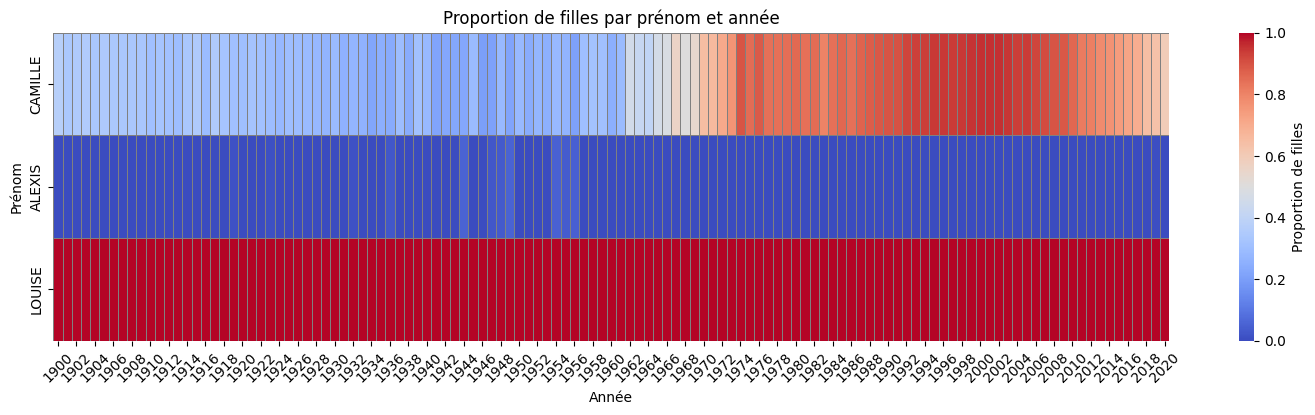

In [ ]:
import seaborn as sns

prenoms = ["CAMILLE", "ALEXIS", "LOUISE", "INES"]
colors = plt.cm.tab10.colors

prenoms_selectionnes = prenoms
df_heatmap = df[df["preusuel"].isin(prenoms_selectionnes)]

pivot = df_heatmap.pivot_table(
    index="preusuel",
    columns=["annais", "sexe"],
    values="nombre",
    aggfunc="sum",
    fill_value=0
)

years = sorted(df_heatmap["annais"].unique())
heatmap_data = []
for prenom in prenoms_selectionnes:
    row = []
    for year in years:
        nb_garcons = pivot.get((year, 1), pd.Series()).get(prenom, 0)
        nb_filles = pivot.get((year, 2), pd.Series()).get(prenom, 0)
        total = nb_garcons + nb_filles
        prop_filles = nb_filles / total if total > 0 else None
        row.append(prop_filles)
    heatmap_data.append(row)

heatmap_df = pd.DataFrame(heatmap_data, index=prenoms_selectionnes, columns=years)

plt.figure(figsize=(18, 4))
sns.heatmap(
    heatmap_df,
    cmap="coolwarm",
    cbar_kws={'label': 'Proportion de filles'},
    linewidths=0.5,
    linecolor='gray',
    vmin=0, vmax=1
)
plt.title("Proportion de filles par prénom et année")
plt.xlabel("Année")
plt.ylabel("Prénom")
plt.xticks(rotation=45)
plt.show()